# Project 3 Task 3 Non-Linear Regression With Scipy Optimize 2024

**Sivert Tilset (273412) and Robel Weldemichael(267200) and Mohammed Jama()**

Date: **10.11.2024**
       

# Abstract
In this task, we investigated the relationships between the variables Vs , DEN , and NEU  with Vp . Our approach involved plotting each pair of variables to visually assess their relationships and determine the most appropriate functional forms for modeling.

Model Selection:

DEN and Vp: The scatter plot suggested a linear relationship but we still have some curves, leading us to select a second-degree polynomial function to model this relationship.

Vs and Vp: The plot indicated a quadratic trend, prompting the choice of a second-degree polynomial function.

NEU and Vp: The data exhibited a pattern consistent with a negative power function, which we deemed suitable for modeling this relationship.

Non-Linear Regression Analysis:

We applied non-linear regression techniques to estimate the coefficients for each selected function using our dataset. The resulting models were then used to predict Vp values. To evaluate the performance of these models, we calculated the coefficient of determination (R²) for each:

Vp_DEN Model: R² = 0.684

Vp_Vs Model: R² = 0.68

Vp_NEU Model: R² = 0.71

These R² values indicate that all three models have a moderate level of predictive accuracy, with the Vp_NEU model performing slightly better.

Comparison with Gardner's Function:

We also evaluated the performance of Gardner's function, a widely used empirical relationship in geophysics, to predict Vp from DEN values. Applying this function to our dataset yielded an R² of -0.74, indicating a poor fit and unreliable predictions.

# Introduction 
Nonlinear regression encompasses a wide range of regression models that do not assume a linear relationship between the dependent and independent variables. When data patterns display curves such as exponential growth or decay, logarithmic trends, or other nonlinear forms applying a nonlinear regression model can more accurately capture these relationships. This approach contrasts with linear regression, which presupposes linearity in the data. [3]



This study aims to investigate the relationships between Vp and three geophysical parameters: shear-wave velocity (Vs), bulk density (DEN), and neutron porosity (NEU). By applying non-linear regression, we seek to construct models that accurately predict Vp from these variables. Depending on the data we will either construct polynomial , logarithmic , exponential or power function for the parameter pairs. Additionally, we will compare the performance of these tailored models against the traditional Gardner's function to assess the efficacy of non-linear regression in capturing the intricacies of our dataset.

# Non-Linear Regression modeling 




In [53]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import curve_fit



In [54]:
# Load the data
df = pd.read_excel('CleanedFeatureSelected.xlsx')

# step 1 :Plot and define the suggested functions

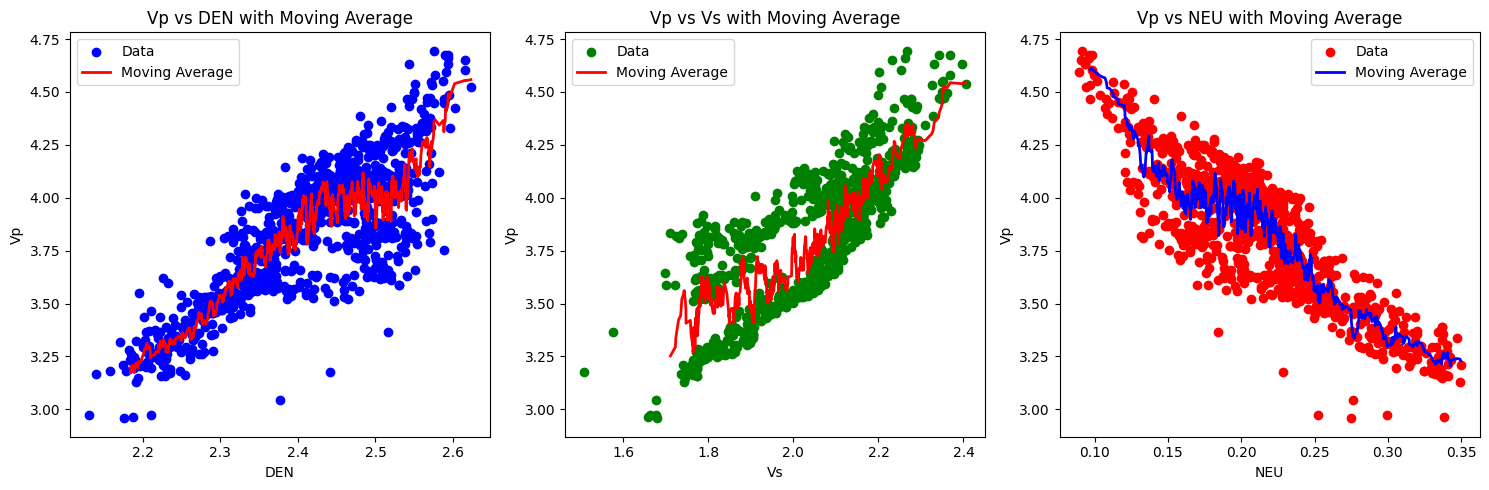

In [55]:

# Define the window size for the moving average
window_size = 10  # Adjust as needed

# Sort the DataFrame by each x-variable to ensure a smooth moving average line
df_sorted_den = df.sort_values(by='DEN')
df_sorted_vs = df.sort_values(by='Vs')
df_sorted_neu = df.sort_values(by='NEU')

# Calculate the moving average for each sorted DataFrame
df_sorted_den['Vp_MA'] = df_sorted_den['Vp'].rolling(window=window_size).mean()
df_sorted_vs['Vp_MA'] = df_sorted_vs['Vp'].rolling(window=window_size).mean()
df_sorted_neu['Vp_MA'] = df_sorted_neu['Vp'].rolling(window=window_size).mean()

# Plot each scatter plot with the moving average line
plt.figure(figsize=(15, 5))

# Vp vs DEN with moving average
plt.subplot(1, 3, 1)
plt.scatter(df['DEN'], df['Vp'], color='blue', label='Data')
plt.plot(df_sorted_den['DEN'], df_sorted_den['Vp_MA'], color='red', linewidth=2, label='Moving Average')
plt.xlabel('DEN')
plt.ylabel('Vp')
plt.title('Vp vs DEN with Moving Average')
plt.legend()

# Vp vs Vs with moving average
plt.subplot(1, 3, 2)
plt.scatter(df['Vs'], df['Vp'], color='green', label='Data')
plt.plot(df_sorted_vs['Vs'], df_sorted_vs['Vp_MA'], color='red', linewidth=2, label='Moving Average')
plt.xlabel('Vs')
plt.ylabel('Vp')
plt.title('Vp vs Vs with Moving Average')
plt.legend()

# Vp vs NEU with moving average
plt.subplot(1, 3, 3)
plt.scatter(df['NEU'], df['Vp'], color='red', label='Data')
plt.plot(df_sorted_neu['NEU'], df_sorted_neu['Vp_MA'], color='blue', linewidth=2, label='Moving Average')
plt.xlabel('NEU')
plt.ylabel('Vp')
plt.title('Vp vs NEU with Moving Average')
plt.legend()

plt.tight_layout()
plt.show()


From the plots :
1. Vp vs DEN: The relationship between Vp and DEN appears mostly linear, with Vp increasing gradually as DEN increases. But we decided to use a second degree polynomial function the catch the curves on the graph.

2. Vp vs Vs: This plot shows a more pronounced curve in the relationship, indicating that a polynomial function would likely be a better fit than a simple linear model. A second-degree polynomial should help model this non-linearity effectively.

3. Vp vs NEU: Unlike the previous two, Vp and NEU exhibit a strong negative relationship, with Vp decreasing as NEU increases. The downward trend suggests that a negative power function would be suitable to capture this inverse relationship.

In [56]:
# Define a first degree polynomial function for Vp vs DEN
def Vp_DEN(x, a, b, c):
     return a * x**2 + b * x + c

# Define a second degree polynomial function  for Vp vs Vs
def Vp_Vs(x, a, b, c):
    return a * x**2 + b * x + c

# Define a negative power function for Vp vs NEU
def Vp_NEU(x, a, b):
    return a * np.power(x, -b)

# step 2 : Unpack the cofficients

In [59]:
# Fit linear to Vp vs DEN using df['DEN'] and df['Vp'] directly
params_den, _ = curve_fit(Vp_DEN, df['DEN'], df['Vp'])
a_den, b_den, c_den = params_den

# Fit polynomial to Vp vs Vs using df['Vs'] and df['Vp'] directly
params_vs, _ = curve_fit(Vp_Vs, df['Vs'], df['Vp'])
a_vs, b_vs, c_vs = params_vs

# Fit negative power function to Vp vs NEU using df['NEU'] and df['Vp'] directly
params_neu, _ = curve_fit(Vp_NEU, df['NEU'], df['Vp'])
a_neu, b_neu = params_neu

# Display optimized parameters
print(f"Optimized parameters for Vp vs DEN : a = {a_den}, b = {b_den}, c = {c_den}")
print(f"Optimized parameters for Vp vs Vs : a = {a_vs}, b = {b_vs}, c = {c_vs}")
print(f"Optimized parameters for Vp vs NEU : a = {a_neu}, b = {b_neu}")

Optimized parameters for Vp vs DEN : a = -2.736560923330664, b = 15.63214135902898, c = -17.91441020058323
Optimized parameters for Vp vs Vs : a = 1.941411612105004, b = -6.162785248908854, c = 8.263744451964154
Optimized parameters for Vp vs NEU : a = 2.531718160483608, b = 0.2614983539637239


# Step 3 : Predicting Vp value and Comparing with the actual Vp value

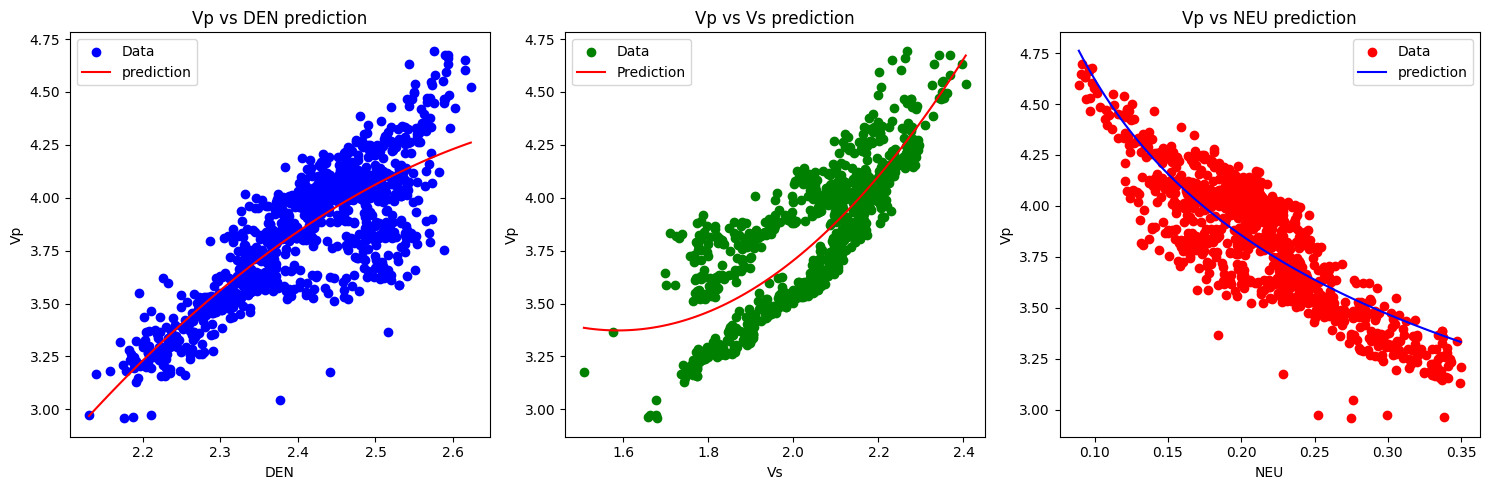

In [61]:

# Generate x-values for smooth curve plotting within the range of each predictor
x_values_den = np.linspace(df['DEN'].min(), df['DEN'].max(), 100)
x_values_vs = np.linspace(df['Vs'].min(), df['Vs'].max(), 100)
x_values_neu = np.linspace(df['NEU'].min(), df['NEU'].max(), 100)

# Calculate the fitted y-values (predictions) using the models
y_model_predicted_den = Vp_DEN(x_values_den, a_den, b_den, c_den)
y_model_predicted_vs = Vp_Vs(x_values_vs, a_vs, b_vs, c_vs)
y_model_predicted_neu = Vp_NEU(x_values_neu, a_neu, b_neu)

# Plot Vp vs DEN with model fit line
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(df['DEN'], df['Vp'], color='blue', label='Data')
plt.plot(x_values_den, y_model_predicted_den, color='red', label='prediction')
plt.xlabel('DEN')
plt.ylabel('Vp')
plt.title('Vp vs DEN prediction')
plt.legend()

# Plot Vp vs Vs with model fit line
plt.subplot(1, 3, 2)
plt.scatter(df['Vs'], df['Vp'], color='green', label='Data')
plt.plot(x_values_vs, y_model_predicted_vs, color='red', label='Prediction')
plt.xlabel('Vs')
plt.ylabel('Vp')
plt.title('Vp vs Vs prediction')
plt.legend()

# Plot Vp vs NEU with model fit line
plt.subplot(1, 3, 3)
plt.scatter(df['NEU'], df['Vp'], color='red', label='Data')
plt.plot(x_values_neu, y_model_predicted_neu, color='blue', label='prediction')
plt.xlabel('NEU')
plt.ylabel('Vp')
plt.title('Vp vs NEU prediction')
plt.legend()

plt.tight_layout()
plt.show()


each prediction align pretty good with the real data suggesting the choosen functions are appropriate for the data pairs.

# Step 4 : Compute Regression coefficient

In [63]:
y_model_predicted_den = Vp_DEN(df['DEN'], a_den, b_den, c_den)
y_model_predicted_vs = Vp_Vs(df['Vs'], a_vs, b_vs, c_vs)
y_model_predicted_neu = Vp_NEU(df['NEU'], a_neu, b_neu)

# Calculate R² score for each model
r2_den = r2_score(df['Vp'], y_model_predicted_den)
r2_vs = r2_score(df['Vp'], y_model_predicted_vs)
r2_neu = r2_score(df['Vp'], y_model_predicted_neu)

# Print the regression coefficients and R² scores
print("Regression Coefficients and R² Scores:")
print(f"Vp vs DEN : Coefficients = (a: {a_den:.3g}, b: {b_den:.3g}), R² = {r2_den:.3g}")
print(f"Vp vs Vs : Coefficients = (a: {a_vs:.3g}, b: {b_vs:.3g}, c: {c_vs:.3g}), R² = {r2_vs:.3g}")
print(f"Vp vs NEU : Coefficients = (a: {a_neu:.3g}, b: {b_neu:.3g}), R² = {r2_neu:.3g}")

Regression Coefficients and R² Scores:
Vp vs DEN : Coefficients = (a: -2.74, b: 15.6), R² = 0.684
Vp vs Vs : Coefficients = (a: 1.94, b: -6.16, c: 8.26), R² = 0.679
Vp vs NEU : Coefficients = (a: 2.53, b: 0.261), R² = 0.71


From the Regression coefficient results we can see that Vp vs NEU model is the most accurate at prediction since it had highest value of reggression coefficients among them So we will take that model and compare it to Gardner's model and see if it outperformes Gardner's model.Based on the regression coefficients and R² scores, the Vp vs NEU model appears to be the most accurate among the fitted models, with the highest R² value of 0.71. This suggests that the Vp vs NEU model captures more variance in the data compared to the other models (Vp vs DEN and Vp vs Vs). As a next step, we’ll compare this Vp vs NEU model with Gardner’s model to determine if it provides a better fit for predicting Vp.

# Step 5 : Comparison to Gardner's model

## Gardner's model [1]
Is a popular function that relates bulk density (DEN) and P-wave velocity and is very popular in petroleum exploration. The function goes as :

$$\rho = 0.23 V_p^{0.25}$$

where Vp is in $feet/s$

In order to use this function for our case we have to rewrite it so that the function solves for V_p.

solving for Vp:

$$V_p = \left( \frac{\rho}{0.23} \right)^4$$

from the values of V_p and DEN we have and the realistic range of the values [2] it looks like V_p is given in $km/s$ and DEN in $g/cm^3$
so in order to use the same function we must change Vp from $feet/s$ to $km/s$:

$$V_p = 0.003048 \left( \frac{\rho}{0.23} \right)^4$$


Gardner's Model R² = -0.7384524227161136


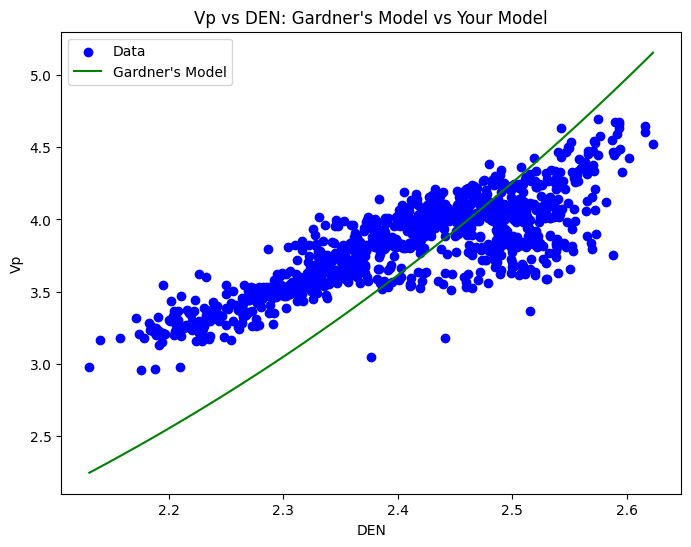

In [50]:
def gardner_model(den):
    return 0.0003048*(den/0.23)**4

# Apply Gardner's model to calculate predicted Vp values
y_gardner_pred = gardner_model(df['DEN'])


# Calculate R² score for Gardner's model
r2_gardner = r2_score(df['Vp'], y_gardner_pred)

# Compare with your model's R² score for Vp vs DEN (Linear Model)

print(f"Gardner's Model R² = {r2_gardner}")

x_values_den = np.linspace(df['DEN'].min(), df['DEN'].max(), 100)
y_gardner_fit = gardner_model(x_values_den)

# Plot original data, Gardner's model, and your linear model fit
plt.figure(figsize=(8, 6))
plt.scatter(df['DEN'], df['Vp'], color='blue', label='Data')
plt.plot(x_values_den, y_gardner_fit, color='green', label="Gardner's Model")
plt.xlabel('DEN')
plt.ylabel('Vp')
plt.title("Vp vs DEN: Gardner's Model vs Your Model")
plt.legend()
plt.show()

The gardner's model prediction was very bad compared to the other models me made . With regration cofficient of -0.74 So it is more ideal to use the models we constructed using non linear regression specially the Vp vs NEU one .

# Discussion and Conclusion
## Discussion
Key learnings for this task include model selection and data visualization , implementaion of non-linear regression, model Evaluation and comparison of models.

Model Selection and Data Visualization:

By plotting each parameter against Vp, We observed distinct patterns that guided the choice of functional forms: a second-degree polynomial for DEN, a second-degree polynomial for Vs, and a negative power function for NEU. This process underscored the significance of data visualization in model selection.

Application of Non-Linear Regression:

Implementing non-linear regression to estimate model coefficients provided hands-on experience with this technique. It reinforced the necessity of understanding the underlying mathematics to ensure accurate model fitting. For instance the knowledge of what type of function yields what type of graf .


Model Evaluation:

Calculating the coefficient of determination (R²) for each model allowed us to assess their predictive performance. The R² values of 0.68 for Vp_DEN, 0.68 for Vp_Vs, and 0.71 for Vp_NEU indicated moderate predictive accuracy, highlighting areas for potential improvement.


Comparison with Empirical Models:

Applying Gardner's function to predict Vp from DEN resulted in an R² of -0.74, demonstrating its inadequacy for this dataset. This comparison emphasized the limitations of gardner's models when applied to this specific datasets.



# Conclusion

The models developed through non-linear regression, tailored to our specific dataset, outperformed Gardner's function in predicting Vp. This outcome aligns with our expectations, as our models were constructed based on the actual relationships observed in our data, whereas Gardner's function is a generalized model not specifically calibrated for our dataset.

In summary, customizing models to the specific characteristics of the dataset can lead to more accurate predictions than applying generalized empirical functions.

# Reflection 

Robel : This project has been instrumental in advancing my proficiency with non-linear regression and its application in geophysical data analysis. It has reinforced the importance of model selection, data visualization, and rigorous evaluation in developing predictive models. Moving forward, I aim to delve deeper into advanced modeling techniques and validation methods to further refine my analytical skills.

# References
[1] : (https://en.wikipedia.org/wiki/Gardner%27s_relation)
[2] : (https://wiki.seg.org/wiki/Porosities%2C_velocities%2C_and_densities_of_rocks)
[3] : (https://www.geeksforgeeks.org/non-linear-regression-examples-ml/)
